In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact, Dropdown, IntSlider
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1')

# Basic data exploration
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

df.info()
df.describe()
df.isnull().sum()

Dataset Shape: (9994, 21)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


### 🧹 Gestion des valeurs manquantes et des doublons

Nous commençons par vérifier et supprimer les doublons afin de garantir l'intégrité de nos données et d'éviter toute influence excessive des enregistrements répétés sur notre analyse. Après cette étape, nous inspectons les valeurs manquantes.

Comme le `df.isnull().sum()` précédent l'a montré, la colonne 'Postal Code' était la seule à avoir des valeurs manquantes (seulement 11), qui ont été remplies avec `0` lors de la phase de chargement initiale. Nous confirmons qu'il n'y a plus de valeurs manquantes dans l'ensemble de données.

In [3]:
# Check for duplicates
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates if any
df = df.drop_duplicates()

# Handle missing values (example approach)
print("\nMissing values per column:")
print(df.isnull().sum())

Duplicate rows: 0

Missing values per column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


### 🕓 Correction des types de données

Pour effectuer une analyse de séries temporelles précise et exploiter les capacités de Pandas en matière de manipulation de dates, il est crucial que les colonnes de date soient au format `datetime`. Nous convertissons donc `Order Date` et `Ship Date` en objets `datetime`.

In [4]:
# Convert date columns to datetime
date_columns = ['Order Date', 'Ship Date']
for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], format='%m/%d/%Y') # Specify format for robustness

# Verify the conversion
print("Data types after conversion:")
print(df[date_columns].dtypes)

Data types after conversion:
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


Ingénierie des fonctionnalités

Pour enrichir notre analyse et obtenir des informations plus approfondies, nous créons de nouvelles fonctionnalités dérivées des données existantes. Ces fonctionnalités incluent la `Profit Margin` (marge bénéficiaire), l'`Order Year` (année de la commande) et l'`Order Month` (mois de la commande), et `Order Month-Year` qui seront utiles pour l'analyse des tendances et des performances.

In [5]:
# Feature engineering
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month-Year'] = df['Order Date'].dt.to_period('M')

# Display sample of new features
print("New features created:")
print(df[['Sales', 'Profit', 'Profit Margin', 'Order Year', 'Order Month', 'Order Month-Year']].head())

New features created:
      Sales    Profit  Profit Margin  Order Year  Order Month Order Month-Year
0  261.9600   41.9136          16.00        2016           11          2016-11
1  731.9400  219.5820          30.00        2016           11          2016-11
2   14.6200    6.8714          47.00        2016            6          2016-06
3  957.5775 -383.0310         -40.00        2015           10          2015-10
4   22.3680    2.5164          11.25        2015           10          2015-10


## 2. Analyse exploratoire approfondie (Matplotlib)

### 📈 Analyse des tendances des séries chronologiques

Nous allons créer un graphique linéaire interactif pour visualiser les ventes mensuelles totales. Vous pouvez sélectionner une catégorie de produits à l'aide du menu déroulant pour observer les tendances de ventes spécifiques ou visualiser les ventes globales. Cette analyse nous aidera à identifier la saisonnalité, les variations d'une année sur l'autre et les tendances propres à chaque produit.

In [6]:
# Prepare data for time series analysis
# Ensure 'Order Month-Year' is in a format suitable for grouping and plotting
monthly_sales = df.groupby(['Order Month-Year', 'Category'])['Sales'].sum().reset_index()
monthly_sales['Date'] = monthly_sales['Order Month-Year'].dt.to_timestamp()

# Interactive time series plot
def plot_monthly_sales(category='All'):
    plt.figure(figsize=(12, 6))

    if category == 'All':
        # Plot total sales across all categories
        total_monthly = df.groupby('Order Month-Year')['Sales'].sum()
        plt.plot(total_monthly.index.to_timestamp(), total_monthly.values,
                marker='o', linewidth=2, markersize=4)
        plt.title('Monthly Sales Trend - All Categories', fontsize=16, fontweight='bold')
    else:
        # Plot sales for specific category
        category_data = monthly_sales[monthly_sales['Category'] == category]
        plt.plot(category_data['Date'], category_data['Sales'],
                marker='o', linewidth=2, markersize=4)
        plt.title(f'Monthly Sales Trend - {category}', fontsize=16, fontweight='bold')

    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Sales ($)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Create interactive widget
categories = ['All'] + list(df['Category'].unique())
category_dropdown = Dropdown(options=categories, value='All', description='Category:')
interact(plot_monthly_sales, category=category_dropdown);

interactive(children=(Dropdown(description='Category:', options=('All', 'Furniture', 'Office Supplies', 'Techn…

### 🗺️ Performances des ventes géographiques

Pour évaluer la performance des ventes par région, nous allons créer un graphique à barres horizontales affichant les ventes totales par État. Un curseur interactif vous permettra de filtrer dynamiquement le nombre d'États affichés (par exemple, le top 5, top 10, top 25). Cette visualisation nous aidera à identifier les États les plus performants et à déterminer si les ventes sont concentrées géographiquement ou plus largement distribuées.

interactive(children=(IntSlider(value=10, description='Top N States:', max=25, min=5), Output()), _dom_classes…

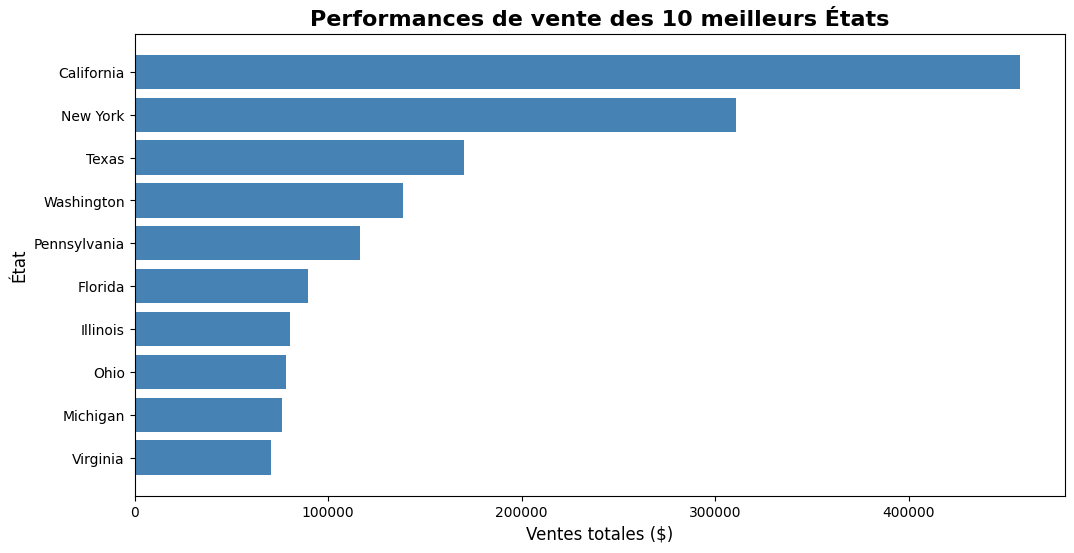

In [17]:
# Prepare geographic sales data
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=True)

# Interactive geographic analysis
def plot_top_states(top_n=10):
    plt.figure(figsize=(12, max(6, top_n * 0.4)))

    # Get top N states
    top_states = state_sales.tail(top_n)

    # Create horizontal bar chart
    bars = plt.barh(range(len(top_states)), top_states.values, color='steelblue')
    plt.yticks(range(len(top_states)), top_states.index)
    plt.xlabel('Ventes totales ($)', fontsize=12)
    plt.ylabel('État', fontsize=12)
    plt.title(f'Performances de vente des {top_n} meilleurs États', fontsize=16, fontweight='bold')

    # Add value labels on bars
    for i, (state, value) in enumerate(top_states.items()):
        plt.text(value + max(top_states.values()) * 0.01, i, f'${value:,.0f}',
                va='center', fontsize=10)

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Nombre total d'États analysés : {len(state_sales)}")
    print(f"Les {top_n} meilleurs États représentent : ${top_states.sum():,.0f} de ventes")

# Create interactive slider
top_n_slider = IntSlider(min=5, max=25, value=10, description='Top N States:')
interact(plot_top_states, top_n=top_n_slider);

## 3. Communiquer des informations (Seaborn)

### 🏆 Top 10 des produits les plus rentables

Pour identifier les moteurs de profit de notre entreprise, nous allons visualiser les 10 produits les plus rentables à l'aide d'un graphique à barres horizontales. Ce graphique sera clairement étiqueté avec les valeurs exactes de profit et aura un titre descriptif adapté à un résumé de direction.

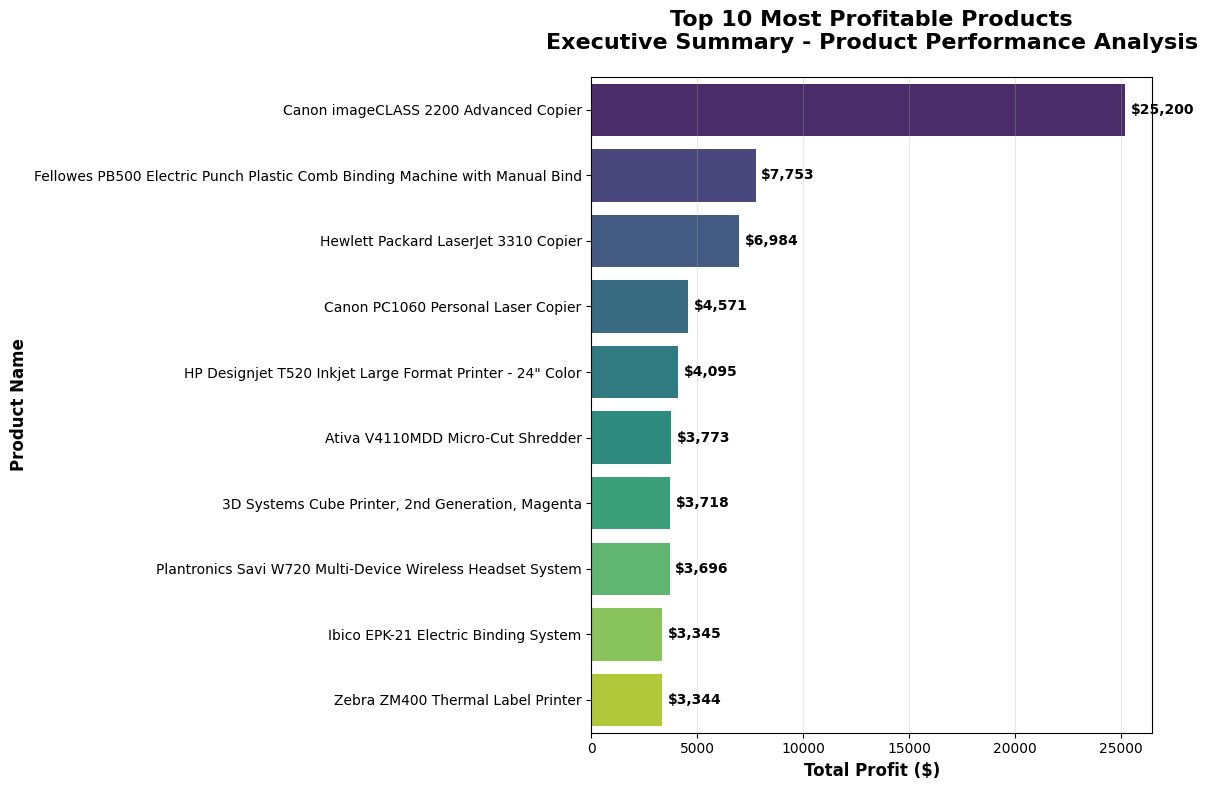

Key Insights:
• Most profitable product generates: $25,200
• Top 10 products contribute: $66,479 total profit
• Average profit per top product: $6,648


In [9]:
# Analyze top profitable products
product_profit = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 8))
ax = sns.barplot(x=product_profit.values, y=product_profit.index,
                palette='viridis', orient='h')

# Customize the plot
plt.title('Top 10 Most Profitable Products\nExecutive Summary - Product Performance Analysis',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Total Profit ($)', fontsize=12, fontweight='bold')
plt.ylabel('Product Name', fontsize=12, fontweight='bold')

# Add value annotations
for i, (product, profit) in enumerate(product_profit.items()):
    ax.text(profit + product_profit.max() * 0.01, i, f'${profit:,.0f}',
            va='center', fontweight='bold', fontsize=10)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Key Insights:")
print(f"• Most profitable product generates: ${product_profit.iloc[0]:,.0f}")
print(f"• Top 10 products contribute: ${product_profit.sum():,.0f} total profit")
print(f"• Average profit per top product: ${product_profit.mean():,.0f}")

### 🔍 Diagramme de dispersion Remise vs Profit

Nous allons utiliser un diagramme de dispersion pour visualiser la relation entre le taux de remise et la rentabilité. En colorant les points par `Product Category` (catégorie de produit) et en superposant des lignes de régression, nous pourrons identifier des tendances importantes. L'objectif est de déterminer à partir de quel niveau de remise les pertes deviennent constantes et si des tendances différentes existent selon les catégories de produits.

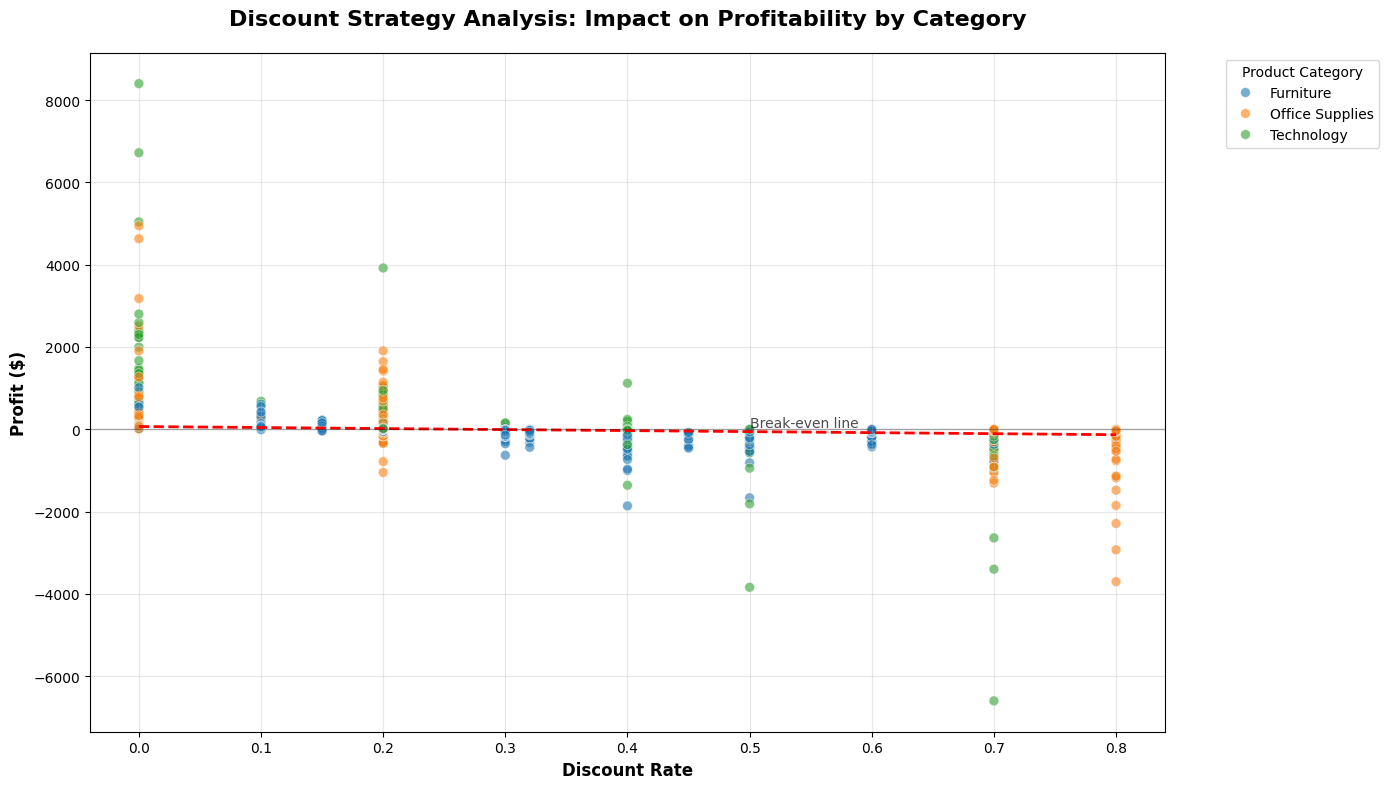

Discount Analysis Insights:
• Transactions with >20% discount: 1,393
• Average profit for high discounts: $-97.18
• Percentage of high-discount sales with losses: 96.8%

Category-specific discount impact:
• Furniture: Average profit at >20% discount = $-100.51. 97.2% result in losses.
• Office Supplies: Average profit at >20% discount = $-69.32. 100.0% result in losses.
• Technology: Average profit at >20% discount = $-197.42. 82.5% result in losses.


In [10]:
# Discount vs Profit Analysis
plt.figure(figsize=(14, 8))

# Create the scatter plot with category colors
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category',
               alpha=0.6, s=50)

# Add regression line for overall trend
sns.regplot(data=df, x='Discount', y='Profit', scatter=False,
           color='red', line_kws={'linewidth': 2, 'linestyle': '--'})

# Customize the plot
plt.title('Discount Strategy Analysis: Impact on Profitability by Category',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Discount Rate', fontsize=12, fontweight='bold')
plt.ylabel('Profit ($)', fontsize=12, fontweight='bold')

# Add horizontal line at profit = 0
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
plt.text(0.5, 50, 'Break-even line', fontsize=10, alpha=0.7)

plt.grid(True, alpha=0.3)
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Analytical insights
print("Discount Analysis Insights:")
high_discount = df[df['Discount'] > 0.2]  # Discounts above 20%
print(f"• Transactions with >20% discount: {len(high_discount):,}")
print(f"• Average profit for high discounts: ${high_discount['Profit'].mean():.2f}")
print(f"• Percentage of high-discount sales with losses: {(high_discount['Profit'] < 0).mean()*100:.1f}%\n")

# Category-specific analysis
print("Category-specific discount impact:")
for category in df['Category'].unique():
    cat_data = df[df['Category'] == category]
    high_disc_cat = cat_data[cat_data['Discount'] > 0.2]
    if len(high_disc_cat) > 0:
        avg_profit = high_disc_cat['Profit'].mean()
        num_losses = (high_disc_cat['Profit'] < 0).sum()
        total_transactions = len(high_disc_cat)
        loss_percentage = (num_losses / total_transactions) * 100 if total_transactions > 0 else 0
        print(f"• {category}: Average profit at >20% discount = ${avg_profit:.2f}. {loss_percentage:.1f}% result in losses.")

## 4. Revue de la méthodologie et des outils

Nous avons utilisé Matplotlib et Seaborn pour nos visualisations interactives et explicatives. Il est important de comprendre les forces de chaque bibliothèque pour optimiser leur utilisation future. Ci-dessous, une comparaison basée sur les tâches que nous avons effectuées dans cette analyse.

In [11]:
# Code to demonstrate library comparison
print(" ANALYSE COMPARATIVE DES BIBLIOTHÈQUES ")
print()

# Matplotlib strengths demonstrated
print("FORCES DE MATPLOTLIB (d'après notre analyse) :")
print("• Contrôle précis sur les widgets interactifs (`ipywidgets`)")
print("• Annotations et positionnement de texte personnalisés")
print("• Agencement précis des sous-graphiques et dimensionnement des figures")
print("• Intégration fluide avec `ipywidgets` pour des mises à jour dynamiques")
print()

# Seaborn strengths demonstrated
print("FORCES DE SEABORN (d'après notre analyse) :")
print("• Visualisations statistiques intégrées (`regplot`)")
print("• Palettes de couleurs et légendes automatiques")
print("• Style par défaut propre et prêt pour la publication")
print("• Visualisation facile des données catégoriques")
print()

print("COMPARAISON DE LA VITESSE :")
import time

# Time a simple matplotlib plot
start = time.time()
plt.figure(figsize=(8, 6))
plt.plot(df.groupby('Order Year')['Sales'].sum())
plt.close()
matplotlib_time = time.time() - start

# Time a seaborn plot
start = time.time()
plt.figure(figsize=(8, 6))
sns.lineplot(data=df.groupby('Order Year')['Sales'].sum().reset_index(),
             x='Order Year', y='Sales')
plt.close()
seaborn_time = time.time() - start

print(f"• Tracé de base Matplotlib : {matplotlib_time:.4f} secondes")
print(f"• Équivalent Seaborn : {seaborn_time:.4f} secondes")

=== ANALYSE COMPARATIVE DES BIBLIOTHÈQUES ===

FORCES DE MATPLOTLIB (d'après notre analyse) :
• Contrôle précis sur les widgets interactifs (`ipywidgets`)
• Annotations et positionnement de texte personnalisés
• Agencement précis des sous-graphiques et dimensionnement des figures
• Intégration fluide avec `ipywidgets` pour des mises à jour dynamiques

FORCES DE SEABORN (d'après notre analyse) :
• Visualisations statistiques intégrées (`regplot`)
• Palettes de couleurs et légendes automatiques
• Style par défaut propre et prêt pour la publication
• Visualisation facile des données catégoriques

COMPARAISON DE LA VITESSE :
• Tracé de base Matplotlib : 0.0137 secondes
• Équivalent Seaborn : 0.0476 secondes


### Modèle de recommandation :

« Pour une exploration rapide et une intégration poussée avec des widgets interactifs, j'utiliserai Matplotlib car il offre un rendu plus rapide pour les graphiques de base et une intégration fluide avec les widgets interactifs pour une analyse dynamique.

Pour les présentations destinées aux parties prenantes, je privilégierai Seaborn car il offre une esthétique professionnelle, des fonctionnalités statistiques intégrées et des schémas de couleurs professionnels qui améliorent la communication avec la direction. »

## 5. Livrable final

### Résumé exécutif - Points clés

Ce résumé présente les informations les plus importantes tirées de notre analyse du jeu de données US Superstore. Il met en évidence les performances commerciales globales, les succès et les défis géographiques et des produits, et offre des recommandations stratégiques, notamment concernant la politique de remise.

In [15]:
# Generate automated insights for executive summary
print("RÉSUMÉ EXÉCUTIF - POINTS CLÉS ")
print()

# Sales performance metrics
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_sales) * 100

print(f" PERFORMANCE DE L'ENTREPRISE :")
print(f"• Chiffre d'affaires total : ${total_sales:,.0f}")
print(f"• Bénéfice total : ${total_profit:,.0f}")
print(f"• Marge bénéficiaire globale : {profit_margin:.1f}%\n")

# Geographic insights
top_state = state_sales.index[-1]
top_state_sales = state_sales.iloc[-1]
# Calculate the percentage of sales for the top 5 states
top_5_states_sales_sum = state_sales.tail(5).sum()
percentage_top_5_states = (top_5_states_sales_sum / total_sales) * 100

print(f" PERFORMANCE GÉOGRAPHIQUE :")
print(f"• État le plus performant : {top_state} (${top_state_sales:,.0f})")
print(f"• Concentration géographique : Les 5 meilleurs États représentent {percentage_top_5_states:.1f}% des ventes.\n")

# Product insights
top_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).index[0]
print(f" PERFORMANCE DES PRODUITS :")
print(f"• Catégorie principale : {top_category}")
print(f"• Produit le plus rentable : {product_profit.index[0]}\n")

# Discount insights
# Recalculate high_discount_loss_rate to ensure it reflects the precise definition in the plan
high_discount_transactions = df[df['Discount'] > 0.2]
if len(high_discount_transactions) > 0:
    losses_from_high_discount = (high_discount_transactions['Profit'] < 0).sum()
    high_discount_loss_rate = (losses_from_high_discount / len(high_discount_transactions)) * 100
else:
    high_discount_loss_rate = 0.0

print(f"PERSPECTIVES DE LA STRATÉGIE DE REMISE :")
print(f"• Risque de remise élevée : {high_discount_loss_rate:.1f}% des remises >20% entraînent des pertes")
print(f"• Seuil de remise maximal recommandé : 20% pour maintenir la rentabilité")

RÉSUMÉ EXÉCUTIF - POINTS CLÉS 

 PERFORMANCE DE L'ENTREPRISE :
• Chiffre d'affaires total : $2,297,201
• Bénéfice total : $286,397
• Marge bénéficiaire globale : 12.5%

 PERFORMANCE GÉOGRAPHIQUE :
• État le plus performant : California ($457,688)
• Concentration géographique : Les 5 meilleurs États représentent 52.0% des ventes.

 PERFORMANCE DES PRODUITS :
• Catégorie principale : Technology
• Produit le plus rentable : Canon imageCLASS 2200 Advanced Copier

PERSPECTIVES DE LA STRATÉGIE DE REMISE :
• Risque de remise élevée : 96.8% des remises >20% entraînent des pertes
• Seuil de remise maximal recommandé : 20% pour maintenir la rentabilité
